# Modelo de Red Neuronal para la predición de atenuación por lluvia en enlaces terrestres

Importación de las librerías

In [133]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from keras import models  
from keras.layers import Dense, Flatten, Activation  
from keras_visualizer import visualizer 
from keras import layers 
from PIL import Image

## Se agrega semilla

Establecer una semilla evita la alietoriedad en los resultados de predicción, es decir, se utiliza para reproducir el experimento.

In [134]:
seed_value= 0
import os
os.environ['PYTHONHASHSEED']=str(seed_value)
import random
random.seed(seed_value)
import numpy as np
np.random.seed(seed_value)
import tensorflow as tf
tf.random.set_seed(seed_value)
from keras import backend as K

tf.config.threading.set_inter_op_parallelism_threads(1)
tf.config.threading.set_intra_op_parallelism_threads(1)

## Exploración de los datos

Se cargan los archivos excel que contienen las mediciones de interés

In [135]:
dt = pd.read_excel('../data/Base-Datos-ITU-R-2016-Atenuacion-Lluvias-Terrestre-Mediciones-Estimaciones-03.xlsx', sheet_name='Medidas-Originales')
df = pd.read_excel('../data/Medidas-Atenuacion-Lluvias-Enlaces-Terrestres.xls', sheet_name='Medidas')

Previsualización de algunos registros contenidos en el archivo en la que a su vez, muestra la cantidad de filas y columnas que tiene el primer documento excel

In [136]:
dt.head(36)
#df.head(36)

,STATION_NO,1101,1101.1,1101.2,1101.3,1101.4,1101.5,1101.6,1101.7,1101.8,...,8035,8036,8037,8038,1,2,3,4,5,1A
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,T_STATION,Mendlesham,Mendlesham,Mendlesham,Mendlesham,Mendlesham,Mendlesham,Mendlesham,Mendlesham,Mendlesham,...,KARAGASAKI,KARAGASAKI,KARAGASAKI,SHIYAKUSYO,PENANG,TEMERLOAH,ALOR STAR,KUALA LUMPUR,TAIPING,JOHOR BAHRU
2,T_CTRY,GB,GB,GB,GB,GB,GB,GB,GB,GB,...,JP,JP,JP,JP,MALAYSA,MALAYSA,MALAYSA,MALAYSA,MALAYSA,MALAYSA
3,T_LATITUDE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,356244,356244,356244,352779,NaN,NaN,NaN,NaN,NaN,NaN
4,T_LONGITUD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,139695,139695,139695,1396753,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,R_STATION,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NAKANO,NAKANO,NAKANO,YRP,PENANG,TEMERLOAH,ALOR STAR,KUALA LUMPUR,TAIPING,JOHOR BAHRU
7,R_CTRY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,JP,JP,JP,JP,MALAYSA,MALAYSA,MALAYSA,MALAYSA,MALAYSA,MALAYSA
8,R_LATITUDE,51.15,51.15,51.15,51.15,51.15,51.15,51.15,51.15,51.15,...,35.7,35.7,35.7,35.22,5.27,3.26,6.15,3.04,4.51,1.3
9,R_LONGITUD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1396664,1396664,1396664,1396808,100.29,100.25,100.25,101.36,100.42,103.43


## Limpieza de los datos

Se realiza con la intención de tener datos 1 a 1, es decir, sin registros vacíos en las columnas que puedan afectar el modelo. Por la naturaleza de los datos, se organizan según el porcentaje de tiempo de lluvia, limpiando el primer dataset.

In [137]:
pares_porcentajes = [
    (17, 27), # 0.001%
    (18, 28), # 0.002%
    (19, 29), # 0.003%
    (20, 30), # 0.006%
    (21, 31), # 0.01%
    (22, 32), # 0.02%
    (23, 33), # 0.03%
    (24, 34), # 0.06%
    (25, 35)  # 0.1% 
]

porcentajes_labels = [0.001, 0.002, 0.003, 0.006, 0.01, 0.02, 0.03, 0.06, 0.1]

fila_f = 11
fila_path = 10

all_rr = []
all_a = []
all_f = []
all_path = []
all_porcentaje = [] 

for i, (idx_rr, idx_a) in enumerate(pares_porcentajes):
    subset = dt.iloc[[idx_rr, idx_a, fila_f, fila_path], 1:94]
    
    subset_clean = subset.apply(pd.to_numeric, errors='coerce').dropna(axis=1)
    
    all_rr.append(subset_clean.iloc[0].values)
    all_a.append(subset_clean.iloc[1].values)
    all_f.append(subset_clean.iloc[2].values)
    all_path.append(subset_clean.iloc[3].values)
    
    all_porcentaje.append(np.full(len(subset_clean.iloc[0]), porcentajes_labels[i]))

rr = np.concatenate(all_rr)
a = np.concatenate(all_a)
f = np.concatenate(all_f)
path_lth = np.concatenate(all_path)
porcentaje_tiempo = np.concatenate(all_porcentaje)

len(a)

709

Para el primer dataset, los datos utilizables luego de la limpieza es de 709 registros. A continuación, se realiza procedimiento similar sobre el segundo dataset.

In [138]:
pares_porcentajes_df = [
    (7, 16), # 0.001%
    (8, 17), # 0.002%
    (9, 18), # 0.003%
    (10, 19), # 0.006%
    (11, 20), # 0.01%
    (12, 21), # 0.02%
    (13, 22), # 0.03%
    (14, 23), # 0.06%
    (15, 24)  # 0.1%
]

porcentajes_labels_df = [0.001, 0.002, 0.003, 0.006, 0.01, 0.02, 0.03, 0.06, 0.1]

df_fila_f = 1
df_fila_path = 0

all_df_rr = []
all_df_a = []
all_df_f = []
all_df_path = []
all_df_porcentaje = [] 

for i, (idx_rr, idx_a) in enumerate(pares_porcentajes_df):
    subset = df.iloc[[idx_rr, idx_a, df_fila_f, df_fila_path], 2:75]
    
    subset_clean = subset.apply(pd.to_numeric, errors='coerce').dropna(axis=1)
    
    all_df_rr.append(subset_clean.iloc[0].values)
    all_df_a.append(subset_clean.iloc[1].values)
    all_df_f.append(subset_clean.iloc[2].values)
    all_df_path.append(subset_clean.iloc[3].values)
    
    all_df_porcentaje.append(np.full(len(subset_clean.iloc[0]), porcentajes_labels_df[i]))

df_rr = np.concatenate(all_df_rr)
df_a = np.concatenate(all_df_a)
df_f = np.concatenate(all_df_f)
df_path_lth = np.concatenate(all_df_path)
df_porcentaje_tiempo = np.concatenate(all_df_porcentaje) 

len(df_a)

551

Para el segundo dataset, los datos utilizables luego de la limpieza son de 551 registros.

## Definición de las entradas y las salidas

Se concatenan los datos de ambos sets en las variables originales (nombradas como las de la primera tabla). Luego se definen las entradas (x : rr, f, path, porcentaje)
 y la salida (y: atenuación).

In [139]:
a = np.concatenate([a, df_a])
rr = np.concatenate([rr, df_rr])
f = np.concatenate([f, df_f])
path_lth = np.concatenate([path_lth, df_path_lth])
porcentaje = np.concatenate([porcentaje_tiempo, df_porcentaje_tiempo])

x1 = pd.Series(rr)            # RR_01
x2 = pd.Series(f)             # F
x3 = pd.Series(path_lth)      # Path
x4 = pd.Series(porcentaje)    # Porcentaje
y = pd.Series(a)              # A_01

muestras = pd.DataFrame({'RR': rr, 'F': f, 'Path': path_lth, 'Porcentaje': porcentaje, 'A': a})

muestras

,RR,F,Path,Porcentaje,A
0,50.0,19.4000,7.40,0.001,18.6
1,50.0,20.1000,16.60,0.001,34.8
2,50.0,22.1000,2.90,0.001,13.9
3,50.0,22.3000,4.00,0.001,17.9
4,50.0,22.1000,7.00,0.001,24.0
...,...,...,...,...,...
1255,26.3,14.5045,18.38,0.100,28.3
1256,28.2,14.5290,21.69,0.100,20.2
1257,26.3,18.5925,7.48,0.100,22.6
1258,28.2,14.5185,42.99,0.100,31.9


Luego de la unión de todos los registros limpos de ambos archivos, queda un total de 1260 muestras utilizables. 

Se definen las entradas (características) y salida (etiqueta) que serán utilizadas en el modelo

In [140]:
muestras.describe()

,RR,F,Path,Porcentaje,A
count,1260.000000,1260.000000,1260.000000,1260.000000,1260.000000
mean,42.543683,27.708887,12.599278,0.027798,20.181278
std,34.366897,24.312719,12.773680,0.032003,12.315791
min,4.500000,7.000000,0.500000,0.001000,0.800000
25%,16.000000,13.185000,2.500000,0.003000,9.900000
50%,33.000000,18.000000,9.500000,0.010000,17.700000
75%,60.000000,33.400000,16.600000,0.030000,29.000000
max,201.000000,137.000000,58.000000,0.100000,56.000000


In [141]:
x3
#x1.shape

0        7.40
1       16.60
2        2.90
3        4.00
4        7.00
        ...  
1255    18.38
1256    21.69
1257     7.48
1258    42.99
1259    42.99
Length: 1260, dtype: float64

Se definen las entradas (características:  las 4 primeras columnas: RR, F, Path, Porcentaje) y salida (etiqueta: la última columna: atenuación) que serán utilizadas en el modelo.

In [142]:
datos = muestras
x = datos.drop('A', axis=1) 
y = datos['A']            

## Gráfica de dispersión

Se grafican en el plano cartesiano las variables relacionadas

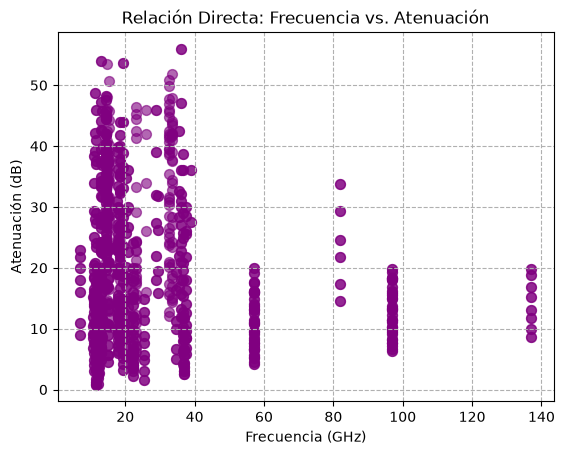

In [143]:
frecuencia = x2
atenuacion = y

plt.scatter(frecuencia, atenuacion, color='purple', marker='o', s=50, alpha=0.6) 
plt.title('Relación Directa: Frecuencia vs. Atenuación')
plt.xlabel('Frecuencia (GHz)')
plt.ylabel('Atenuación (dB)')
plt.grid(True, linestyle='--')
plt.show()

## Separación de datos para entrenamiento y evaluación

Se realiza la división de los datos: 80% para entrenamiento (x_train y y_train) y el 20% para evaluación (x_test y y_test). Se hace uso de una semilla para garantizar que la secuencia numérica aleatoria (división de datos) sea la misma cada vez.

In [144]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2, 
    random_state=42)

In [145]:
model_results = [["Entradas", len(x), len(x_train), len(x_test)],
                 ["Salidas", len(y), len(y_train), len(y_test)]]
tabla = pd.DataFrame(model_results, columns=["Datos", "Total Muestras (100%)", 
                                             "Muestras train (80%)", "Muestras test (20%)" ])
tabla

,Datos,Total Muestras (100%),Muestras train (80%),Muestras test (20%)
0,Entradas,1260,1008,252
1,Salidas,1260,1008,252


Guardar los datos de evaluación en un archivo Excel.


In [146]:
x_test

x_test_xlsx = pd.DataFrame({
    'Porcentaje de tiempo (%)': x_test['Porcentaje'].values,
    'RR': x_test['RR'].values,
    'Frecuencia (GHz)': x_test['F'].values,
    'Distancia': x_test['Path'].values,
    'Atenuación medida (dB)': y_test.values
})

x_test_xlsx = x_test_xlsx.sort_values(by='Porcentaje de tiempo (%)')
x_test_xlsx.to_excel('../src/x_test.xlsx', index=False)
print('Archivo x_test.xlsx guardado con éxito.')  

Archivo x_test.xlsx guardado con éxito.


In [147]:
x_test

,RR,F,Path,Porcentaje
76,75.00,17.80,9.50,0.002
1026,26.00,25.30,2.50,0.020
43,115.33,23.20,1.20,0.001
666,5.60,13.14,43.80,0.100
529,30.81,32.60,2.10,0.030
...,...,...,...,...
430,60.20,14.53,21.69,0.020
32,75.20,13.03,39.40,0.001
156,50.00,57.00,0.50,0.003
376,17.00,10.80,15.00,0.020


In [148]:
y_test

76      25.60
1026     5.70
43      24.29
666      6.90
529     23.71
        ...  
430     34.60
32      42.70
156     19.20
376      6.80
620     16.52
Name: A, Length: 252, dtype: float64

## Escalado de los datos

Se exploran las escalas de los valores mínimos y máximos.

In [149]:
for col in datos.columns[0:]:
    min = datos[col].min()
    max = datos[col].max()
    print(f'máx/min columna "{col}":{max:.1f}/{min:.1f}')

máx/min columna "RR":201.0/4.5
máx/min columna "F":137.0/7.0
máx/min columna "Path":58.0/0.5
máx/min columna "Porcentaje":0.1/0.0
máx/min columna "A":56.0/0.8


El escalado es esencial para que las Redes Neuronales entrenen de manera eficiente

In [150]:
scaler_x = StandardScaler()
scaler_y = StandardScaler()

x_train_norm = scaler_x.fit_transform(x_train.drop('Porcentaje', axis=1).values)
y_train_norm = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()

x_test_norm = scaler_x.transform(x_test.drop('Porcentaje', axis=1).values)     
y_test_norm = scaler_y.transform(y_test.values.reshape(-1, 1)).flatten()

## Defición del modelo RNA

In [151]:
modelo = tf.keras.Sequential([
    tf.keras.Input(shape=[3]),  # Entrada explícita
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])
# Exportar gráfica del modelo
visualizer(modelo, file_name='../src/model-rna-graph',file_format='png')

In [152]:
print("\nModelo con tres entradas, tres capas ocultas y una salida.")
modelo.summary()


Modelo con tres entradas, tres capas ocultas y una salida.


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,353 (17.00 KB)

 Trainable params: 4,353 (17.00 KB)

 Non-trainable params: 0 (0.00 B)

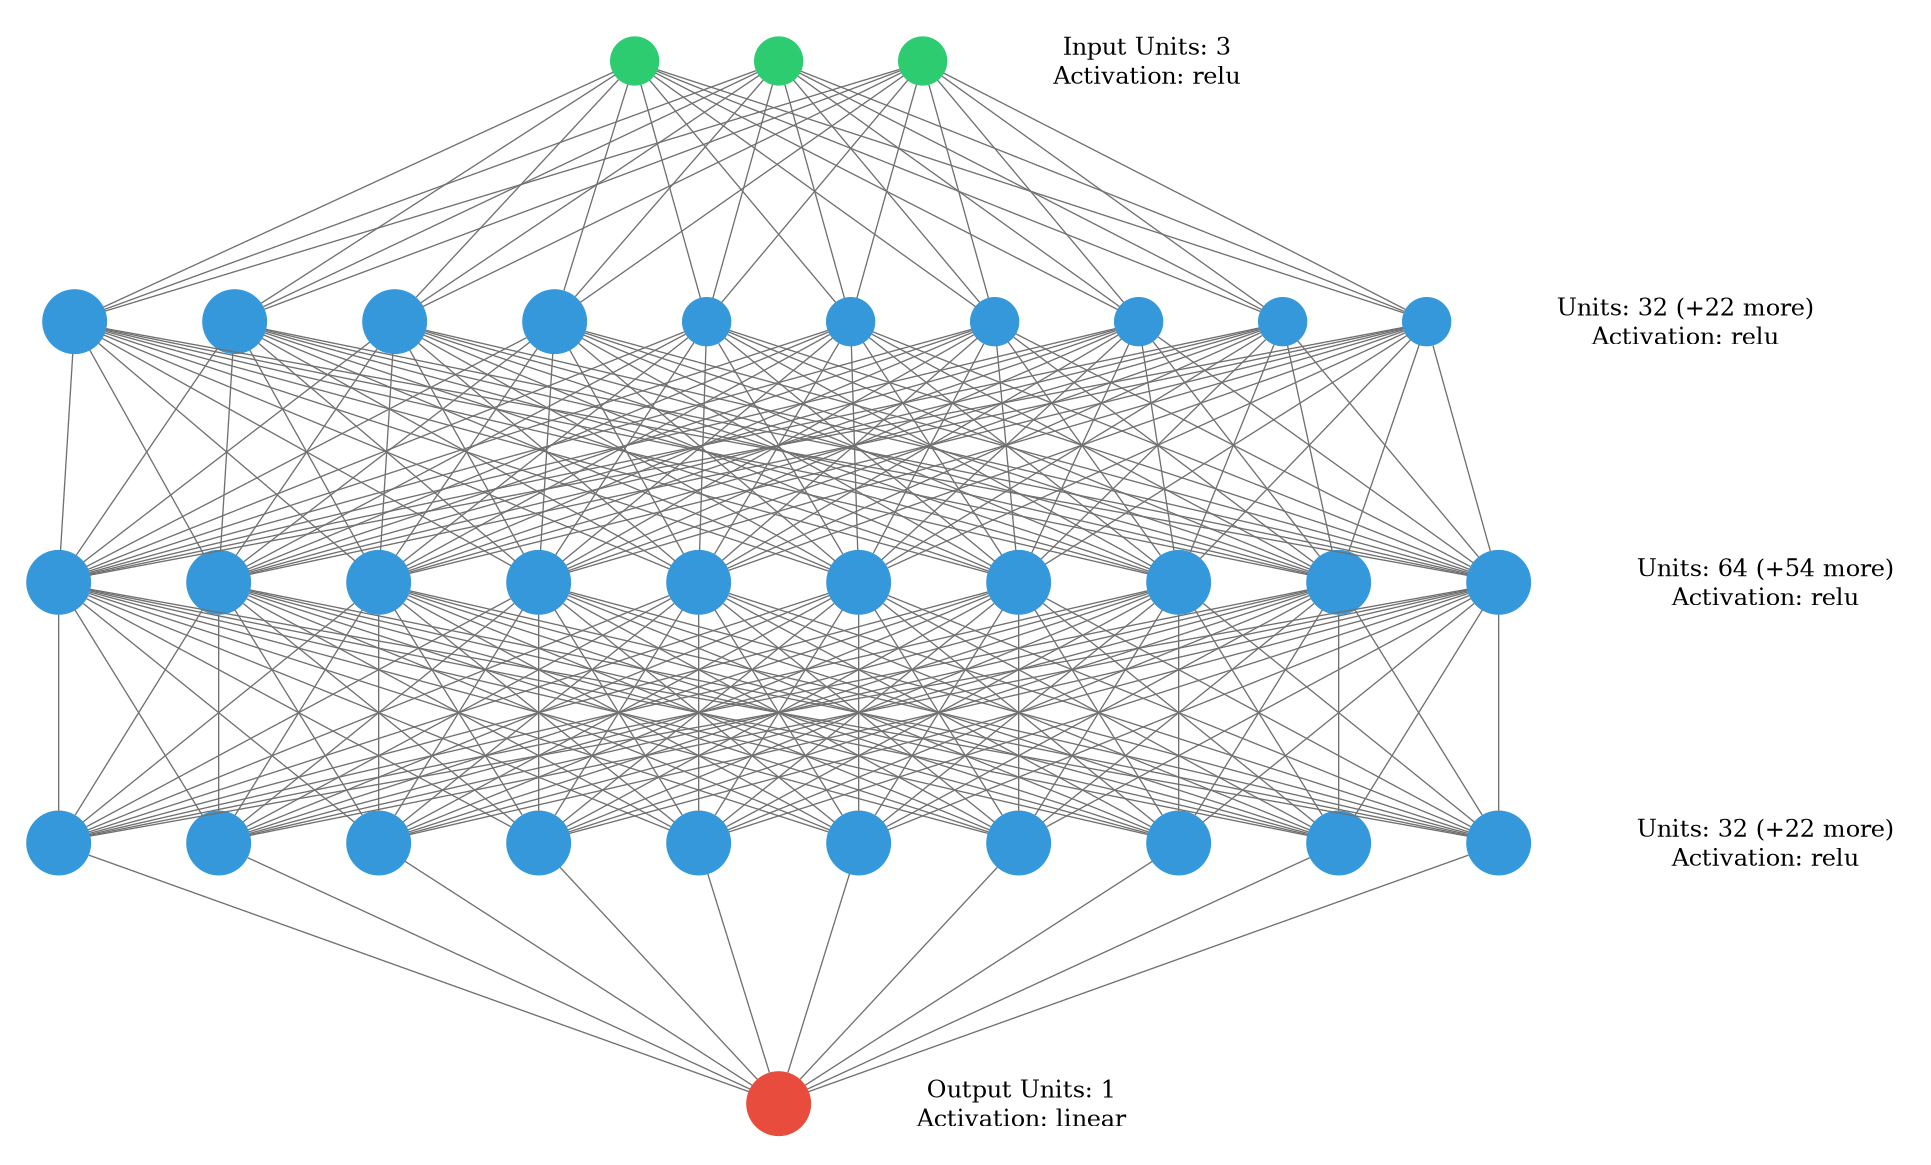

In [153]:
path_image='../src/model-rna-graph.png'
diagram = Image.open(path_image)
diagram

## Compilación y entrenamiento del modelo 

Se compila y entrena el modelo posterior a su definición, utilizando Adam como optimizador, el Error Cuadrático Medio (MSE) por sus siglas en inglés como la pérdida y finalmente como parámetro de métrica la Raíz del Error Cuadrático Medio (RMSE).

In [154]:
modelo.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss='mean_squared_error',
    metrics=['RootMeanSquaredError'] 
)

In [155]:
print('Comenzando entrenamiento...')
print('Puede tardar unos minutos...')
historial = modelo.fit(x_train_norm, y_train_norm,epochs=1500, batch_size=64, verbose=False) #, batch_size=64)
print('¡Entrenamiento finalizado!')

Comenzando entrenamiento...
Puede tardar unos minutos...
¡Entrenamiento finalizado!


## Prueba del modelo

A continuación, se comprueba el entrenamiento en el que se evalúa si la salida es lo más cercana a los valores medidos para corrobar qué tan bien entrenado quedó el modelo.

In [156]:
print('Probando')
entrada = np.array(x_test.drop('Porcentaje', axis=1))
entrada_norm = scaler_x.transform(entrada)
resultado_norm = modelo.predict(entrada_norm)
resultado = scaler_y.inverse_transform(resultado_norm)

Probando
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


In [157]:
resultados_comp = pd.DataFrame({
    'Porcentaje de lluvia (%)': x_test['Porcentaje'].values,
    'RR': x_test['RR'].values,
    'Predicción (dB)': resultado.flatten(),
    'Real (dB)': y_test.values
})

# Ordenar resultados por porcentaje de menor a mayor
resultados_comp = resultados_comp.sort_values(by='Porcentaje de lluvia (%)')


# Guardar resultados en un archivo Excel
try:
    resultados_comp.to_excel('../src/test-comparacion.xlsx', index=False)
    print('Archivo test-comparacion.xlsx guardado con éxito.')
except Exception as e:
    print(f'Error al guardar Excel: {e}')
    print('Asegúrate de tener instalada la librería openpyxl: pip install openpyxl')
    
resultados_comp

Archivo test-comparacion.xlsx guardado con éxito.


,Porcentaje de lluvia (%),RR,Predicción (dB),Real (dB)
2,0.001,115.33,20.351261,24.29
60,0.001,98.00,10.312666,6.30
52,0.001,166.00,38.674316,37.94
104,0.001,61.00,35.522240,33.40
122,0.001,50.00,28.182686,30.00
...,...,...,...,...
207,0.100,4.50,9.735570,8.60
222,0.100,28.20,20.582279,21.20
218,0.100,26.30,17.205479,22.60
212,0.100,8.00,9.198932,8.70


## Graficar la función de pérdida

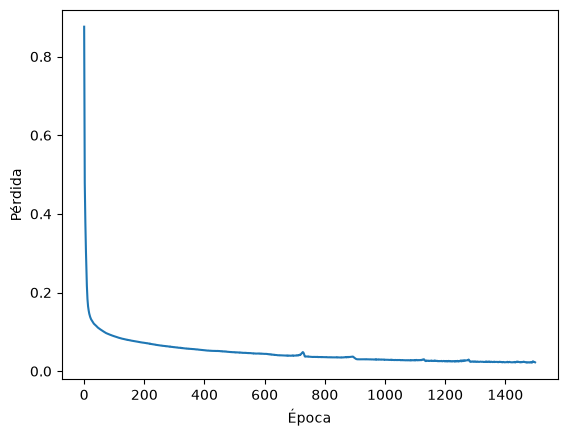

In [158]:
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.plot(historial.history['loss'])

## Cálculo del Error Cuadrático Absoluto

In [159]:
# Cálculo del MAE (Mean Absolute Error) Error Absoluto Medio
mae = tf.reduce_mean(tf.abs(y_test.values.flatten() - resultado.flatten()))
#mae

In [160]:
# Cálculo del MAE (Mean Absolute Error) Error Absoluto Medio
# Para obtener un solo valor y no todos
mae = tf.reduce_mean(tf.abs(y_test.values.flatten() - resultado.flatten().squeeze()))
mae

<tf.Tensor: shape=(), dtype=float64, numpy=1.9419925252218093>

## Cálculo del Error Cuadrático Medio

In [161]:
# Cálculo del MSE (Mean Square Error) Error Cuadrático Medio
mse = tf.reduce_mean(tf.square(y_test.values.flatten() - resultado.flatten()))
#mse

In [162]:
# Cálculo del MSE (Mean Square Error) Error Cuadrático Medio
# Para obtener un solo valor y no todos
mse = tf.reduce_mean(tf.square(y_test.values.flatten() - resultado.flatten().squeeze()))
#mse = mse.numpy()
mse

<tf.Tensor: shape=(), dtype=float64, numpy=8.821359500199165>

In [163]:
#resultado.shape

## Evaluación del entrenamiento y prueba

In [164]:
# Evaluar el modelo en el set de entrenamiento
score_train = modelo.evaluate(x_train_norm, y_train_norm)
#print('Train Score:', score_train)
#score_train

# Evaluar el modelo en el set de pruebas
score_test = modelo.evaluate(x_test_norm, y_test_norm)
#print('Test Score:', score_test)
#score_test

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.1478 - loss: 0.0218  
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - RootMeanSquaredError: 0.2405 - loss: 0.0578 


In [165]:
print(historial.history.keys())

dict_keys(['RootMeanSquaredError', 'loss'])


In [166]:
print('Pérdida: ', historial.history['loss'][-1], '\nMétrica: ', historial.history['RootMeanSquaredError'][-1])

Pérdida:  0.02247583121061325 
Métrica:  0.14991942048072815


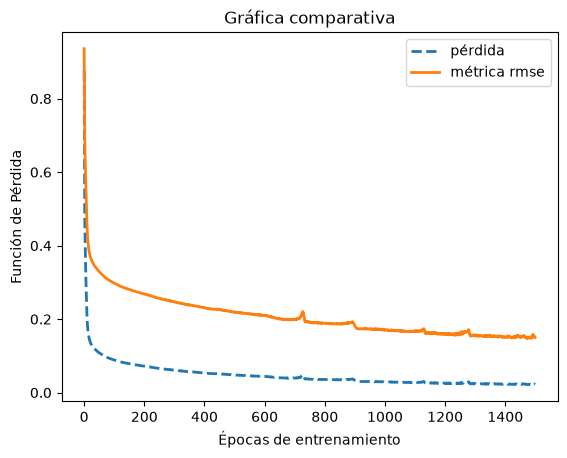

In [167]:
plt.plot(historial.history['loss'], lw =2, ls = '--', label = 'pérdida')
plt.plot(historial.history['RootMeanSquaredError'], lw =2, ls = '-', label = 'métrica rmse')
plt.xlabel('Épocas de entrenamiento')#, fontsize=15)
plt.ylabel('Función de Pérdida')#, fontsize=15)
plt.title('Gráfica comparativa')
plt.legend()

## Resumen del modelo (parámetros)

In [168]:
model_results = [["RNA", mae.numpy(), mse.numpy(), score_train[1], score_test[1]]]
all_results = pd.DataFrame(model_results, columns=["Modelo", "MAE", "MSE", "RMSE_train", "RMSE_test"])
all_results

,Modelo,MAE,MSE,RMSE_train,RMSE_test
0,RNA,1.941993,8.82136,0.147755,0.240451


## Gráfica de dispersión comparativa

In [169]:
datos_test = x_train
x_train_f = x_train.drop(['RR', 'Path', 'Porcentaje'], axis=1) 

In [170]:
datos_test = x_test
x_test_f = x_test.drop(['RR', 'Path','Porcentaje'], axis=1) 

Se importa el modelo ya entrenado para ser intregado como núcleo en app web.

In [171]:
import joblib
import os

# Guardar el modelo y scalers
model_dir = '../model_trained/atn-model_web/app/model'
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

print("Guardando modelo...")
modelo.save(os.path.join(model_dir, 'model.keras'))
joblib.dump(scaler_x, os.path.join(model_dir, 'scaler_x.pkl'))
joblib.dump(scaler_y, os.path.join(model_dir, 'scaler_y.pkl'))
print("✓ Modelo guardado exitosamente")

Guardando modelo...
✓ Modelo guardado exitosamente
